In [73]:
# import kagglehub
# path = kagglehub.dataset_download('abhi8923shriv/sentiment-analysis-dataset')
# print('Path to dataset files:', path)

### Описание набора данных и решаемой задачи:

Набор данных: 'Tweet Sentiment Dataset'. Это набор данных, содержащий около 27,500 твитов на английском языке с ручной разметкой тональности. Исходный файл – train.csv.

Цель: Исследовать эффективность моделей машинного обучения для задачи классификации тональности коротких сообщений (твитов) на английском языке и разработать прототип системы онлайн-мониторинга.

Целевая переменная: sentiment (настроение), которая принимает 3 значения:
* positive (Позитив) -> 2
* neutral (Нейтрально) -> 1
* negative (Негатив) -> 0

### Метрики качества для модели:

Accuracy: Общая доля правильных ответов.

Accuracy = (TP + TN) / (TP + TN + FP + FN)

---

F1-score: Для этой задачи это главная метрика. Так как классы могут быть несбалансированы (обычно нейтральных новостей больше), нам важно среднее качество по всем трем классам, без учета их размера.

F1 = 2 * (Precision * Recall) / (Precision + Recall)


### Ориентиры:

Минимальный уровень:

Accuracy  > 0.70

Macro F1 > 0.65

Целевой уровень:

Accuracy > 0.75

Macro F1 > 0.75

### Загрузка библиотек и датасета:

In [120]:
!pip install catboost transformers sentencepiece

In [121]:
import pandas as pd
import numpy as np
import re
import time
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (classification_report, confusion_matrix, f1_score, accuracy_score, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn.functional as F
from transformers import BertTokenizer, AutoModel
from catboost import CatBoostClassifier

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [122]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from torch.utils.data import TensorDataset, DataLoader

In [123]:
data_raw = pd.read_csv('train.csv', encoding='latin-1')

In [124]:
data_raw.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


###Предварительный анализ и очистка данных:

In [125]:
print('Размер:', data_raw.shape)

Размер: (27481, 10)


In [126]:
print('Дубликаты:', data_raw.duplicated().sum())
print(data_raw.isnull().sum())

Дубликаты: 0
textID              0
text                1
selected_text       1
sentiment           0
Time of Tweet       0
Age of User         0
Country             0
Population -2020    0
Land Area (Km²)     0
Density (P/Km²)     0
dtype: int64


In [127]:
data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   textID            27481 non-null  object 
 1   text              27480 non-null  object 
 2   selected_text     27480 non-null  object 
 3   sentiment         27481 non-null  object 
 4   Time of Tweet     27481 non-null  object 
 5   Age of User       27481 non-null  object 
 6   Country           27481 non-null  object 
 7   Population -2020  27481 non-null  int64  
 8   Land Area (Km²)   27481 non-null  float64
 9   Density (P/Km²)   27481 non-null  int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 2.1+ MB


In [128]:
df = data_raw[['text', 'sentiment']].copy()

In [129]:
df = df.dropna(subset=['text', 'sentiment'])

In [130]:
# Маппинг меток: слова в числа
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
reverse_label_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

In [131]:
df['label'] = df['sentiment'].map(label_map)

In [132]:
data = df.reset_index(drop=True)

####Анализ дисбаланса классов:

/tmp/ipython-input-851044102.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=data, palette='viridis', order=['negative', 'neutral', 'positive'])


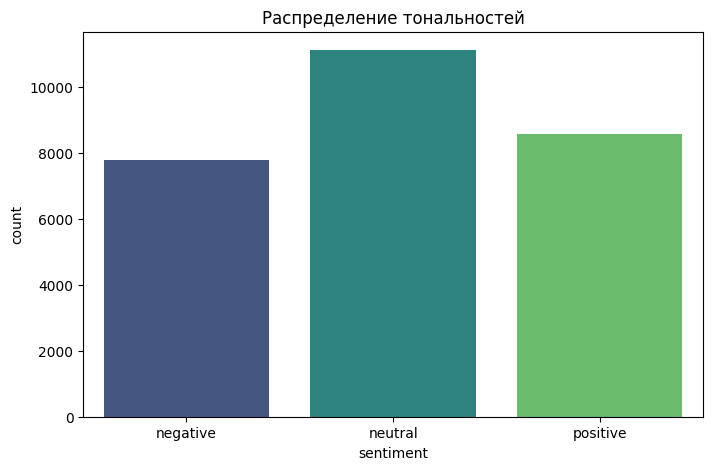

In [133]:
plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment', data=data, palette='viridis', order=['negative', 'neutral', 'positive'])
plt.title('Распределение тональностей')
plt.show()

### Преобразование данных:
Для анализа текстовых данных необходимо преобразовать их в числовой формат. Используем токенизатор от BERT (bert-base-uncased для английского).


In [134]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
MAX_LEN = 128

def tokenize_texts(texts):
    encodings = tokenizer(
        list(texts),
        truncation=True, # обрезать текст
        padding='max_length', # дополнять тексты
        max_length=MAX_LEN,
        return_tensors='pt' # возвращение в виде PyTorch тензоров
    )
    return encodings['input_ids'], encodings['attention_mask']

###Разделение набора данных:

Данные разделяются на три части:

Обучающая выборка (Training set) 80%: Используется для обучения модели, т.е. для подбора ее весов/параметров.

Валидационная выборка (Validation set) 10%: Используется для настройки гиперпараметров модели (например, количество эпох, скорость обучения, параметры регуляризации) и для отслеживания переобучения в процессе тренировки. Модель не обучается напрямую на этих данных, но они влияют на выбор лучшей конфигурации модели.

Тестовая выборка (Test set) 10%: Используется для финальной, независимой оценки качества обученной и настроенной модели. Эти данные модель 'видит' только один раз, после завершения всех этапов обучения и настройки.



In [135]:
texts = list(data['text'])
labels = np.array(data['label'])

X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.2, random_state=15, stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=15, stratify=y_temp)

print(f'Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}')

Train: 21984, Val: 2748, Test: 2748


### Принципиальная архитектура нейросетевой модели:
Адаптируем класс SentimentClassifier под 3 выхода

In [136]:
# Класс модели для классификации тональности
class SentimentClassifier(nn.Module):
    def __init__(self, model_name='bert-base-uncased', n_classes=3, dropout=0.5):
        super().__init__() # вызов родительского класса
        self.bert = AutoModel.from_pretrained(model_name) # предобученная модель BERT
        self.dropout = nn.Dropout(dropout) # регуляризация
        self.classifier = nn.Linear(self.bert.config.hidden_size, n_classes) # линейный слой

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask) # пропускает токены через BERT
        pooled = outputs.pooler_output # берется эмбеддинг
        return self.classifier(self.dropout(pooled)) # предсказывает метку

###Возможные варианты модификации модели:

1. Изменение архитектуры:

Добавление большего количества линейных слоев (например, Linear -> ReLU -> Dropout -> Linear).

Использование других функций активации (например, GeLU).

2. Заморозка большего количества слоев BERT: По умолчанию при fine-tuning обучаются все слои BERT. Можно попробовать заморозить часть нижних слоев BERT, обучая только верхние и классификационную голову.

3. Использование другой предобученной модели BERT.

### Реализация модели и процесса обучения на PyTorch:

In [137]:
# Кастомный Dataset для работы с BERT и PyTorch
class BertDataset(Dataset):
    def __init__(self, texts, labels):
        self.input_ids, self.attn_masks = tokenize_texts(texts) # токенизация
        self.labels = torch.tensor(labels, dtype=torch.long) # метки в тензор

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attn_masks[idx],
            'labels': self.labels[idx]
        }

In [138]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_correct = 0.0, 0
    for batch in loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), total_correct / len(loader.dataset)

In [139]:
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct = 0.0, 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            total_correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), total_correct / len(loader.dataset)

### Процесс обучения:

In [140]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_ds = BertDataset(X_train, y_train)
val_ds = BertDataset(X_val, y_val)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)

model = SentimentClassifier(n_classes=3).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

EPOCHS = 3
best_val_acc = 0.0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    start_t = time.time()
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_bert_model.pth')

    print(f'Epoch {epoch}/{EPOCHS} | T: {time.time() - start_t:.1f}s | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

Epoch 1/3 | T: 451.0s | Train Loss: 0.6263 Acc: 0.7353 | Val Loss: 0.5063 Acc: 0.7937
Epoch 2/3 | T: 435.2s | Train Loss: 0.4426 Acc: 0.8246 | Val Loss: 0.5367 Acc: 0.7886
Epoch 3/3 | T: 434.4s | Train Loss: 0.3202 Acc: 0.8808 | Val Loss: 0.5733 Acc: 0.7820


### Оценка качества (RuBERT):

In [141]:
model.load_state_dict(torch.load('best_bert_model.pth'))
model.eval()
test_ds = BertDataset(X_test, y_test)
test_loader = DataLoader(test_ds, batch_size=32)

all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(input_ids, attention_mask)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=['Negative', 'Neutral', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.79      0.85      0.82       778
     Neutral       0.78      0.76      0.77      1112
    Positive       0.84      0.82      0.83       858

    accuracy                           0.80      2748
   macro avg       0.81      0.81      0.81      2748
weighted avg       0.80      0.80      0.80      2748



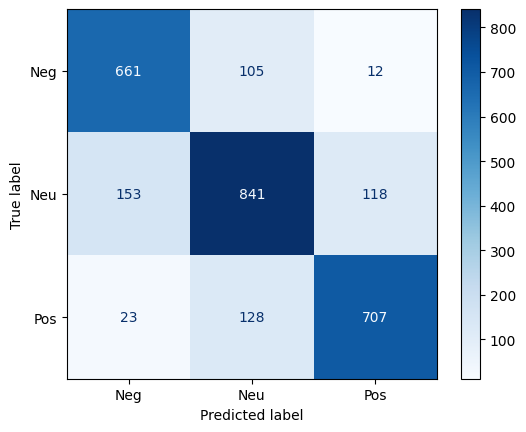

In [142]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Neg', 'Neu', 'Pos'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

### Проверка на переобучение:

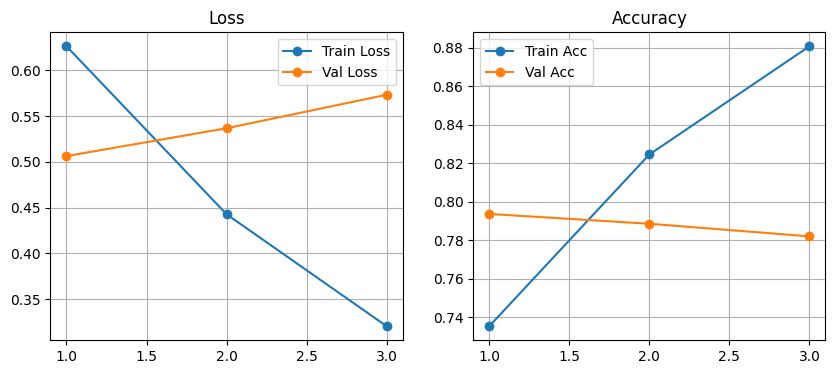

In [143]:
epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
plt.plot(epochs_range, history['val_loss'], label='Val Loss', marker='o')
plt.title('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Train Acc', marker='o')
plt.plot(epochs_range, history['val_acc'], label='Val Acc', marker='o')
plt.title('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### Обучение и оценка качества для нескольких альтернативных архитектур:

Для начала подготовим данные для классических моделей (TF-IDF). Они не требуют GPU и обучаются быстро, что хорошо для сравнения с RuBERT

In [144]:
# Предобработка текста
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text) # Удаляем ссылки
    text = re.sub(r'[^\w\s]', '', text) # Удаляем пунктуацию
    return text

data['cleaned_text'] = data['text'].apply(preprocess_text)

In [145]:
# Векторизация TF-IDF (English stopwords)
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(data['cleaned_text']).toarray()
y = data['label'].values

In [146]:
# Разделение выборки
X_train_alt, X_test_alt, y_train_alt, y_test_alt = train_test_split(
    X_tfidf, y, test_size=0.2, stratify=y, random_state=15)

print('Размерность обучающей выборки:', X_train_alt.shape)

Размерность обучающей выборки: (21984, 5000)


#### 1. Logistic Regression (Логистическая регрессия)

In [147]:
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, multi_class='multinomial')
lr_model.fit(X_train_alt, y_train_alt)
y_pred_LR = lr_model.predict(X_test_alt)
print('LogReg:', classification_report(y_test_alt, y_pred_LR))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogReg:               precision    recall  f1-score   support

           0       0.68      0.66      0.67      1556
           1       0.65      0.67      0.66      2223
           2       0.74      0.73      0.73      1717

    accuracy                           0.69      5496
   macro avg       0.69      0.69      0.69      5496
weighted avg       0.69      0.69      0.69      5496



#### 2. CatBoost

In [148]:
model_CB = CatBoostClassifier(iterations=200, learning_rate=0.1, depth=6, verbose=0, auto_class_weights='Balanced')
model_CB.fit(X_train_alt, y_train_alt)
y_pred_CB = model_CB.predict(X_test_alt).flatten()
print('CatBoost:', classification_report(y_test_alt, y_pred_CB))

CatBoost:               precision    recall  f1-score   support

           0       0.77      0.52      0.62      1556
           1       0.60      0.79      0.68      2223
           2       0.75      0.68      0.71      1717

    accuracy                           0.68      5496
   macro avg       0.71      0.66      0.67      5496
weighted avg       0.70      0.68      0.67      5496



#### 3. LinearSVC (Метод опорных векторов)


In [149]:
param_grid = {
    'C': [0.1, 1, 10],  # Параметр регуляризации
    'loss': ['hinge', 'squared_hinge'], # Функция потерь
    'class_weight': ['balanced', None] # Балансировка классов
}

In [150]:
grid_search = GridSearchCV(
    estimator=LinearSVC(max_iter=3000, dual='auto'), # dual='auto' выбирает лучший алгоритм
    param_grid=param_grid,
    cv=3, # Кросс-валидация на 3 фолда
    scoring='f1_macro', # Оптимизируем F1 Macro
    n_jobs=-1
)

In [151]:
grid_search.fit(X_train_alt, y_train_alt)
print(f'Лучшие параметры SVM: {grid_search.best_params_}')

Лучшие параметры SVM: {'C': 0.1, 'class_weight': 'balanced', 'loss': 'hinge'}


In [152]:
model_SVC = grid_search.best_estimator_
y_pred_SVC = model_SVC.predict(X_test_alt)
print('SVM:', classification_report(y_test_alt, y_pred_SVC))

SVM:               precision    recall  f1-score   support

           0       0.70      0.67      0.68      1556
           1       0.68      0.66      0.67      2223
           2       0.71      0.78      0.74      1717

    accuracy                           0.70      5496
   macro avg       0.70      0.70      0.70      5496
weighted avg       0.70      0.70      0.70      5496



#### 4. SimpleNN (Простая нейросеть на PyTorch)

In [153]:
# Тензоры
X_train_t = torch.tensor(X_train_alt, dtype=torch.float32)
X_test_t = torch.tensor(X_test_alt, dtype=torch.float32)
y_train_t = torch.tensor(y_train_alt, dtype=torch.long)

# Создаем DataLoader (для обучения мини-батчами)
train_dataset_nn = TensorDataset(X_train_t, y_train_t)
train_loader_nn = DataLoader(train_dataset_nn, batch_size=64, shuffle=True)

In [154]:
class SimpleNN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 3)
        )
    def forward(self, x):
        return self.model(x)

In [155]:
model_NN = SimpleNN(input_size=X_train_alt.shape[1])
opt_nn = optim.Adam(model_NN.parameters(), lr=0.001)
crit_nn = nn.CrossEntropyLoss()

In [156]:
for ep in range(15):
    model_NN.train()
    for xb, yb in train_loader_nn:
        opt_nn.zero_grad()
        loss = crit_nn(model_NN(xb), yb)
        loss.backward()
        opt_nn.step()

In [157]:
model_NN.eval()
with torch.no_grad():
    y_pred_NN = torch.argmax(model_NN(X_test_t), dim=1).numpy()
print('SimpleNN:', classification_report(y_test_alt, y_pred_NN))

SimpleNN:               precision    recall  f1-score   support

           0       0.68      0.59      0.63      1556
           1       0.61      0.67      0.64      2223
           2       0.70      0.69      0.70      1717

    accuracy                           0.65      5496
   macro avg       0.66      0.65      0.65      5496
weighted avg       0.66      0.65      0.65      5496



### Сбор и визуализация результатов:

In [158]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

In [159]:
def get_metrics(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Macro F1': f1_score(y_true, y_pred, average='macro')
    }

In [160]:
metrics_list = []
metrics_list.append(get_metrics(y_test_alt, y_pred_LR, 'Logistic Regression'))
metrics_list.append(get_metrics(y_test_alt, y_pred_CB, 'CatBoost'))
metrics_list.append(get_metrics(y_test_alt, y_pred_SVC, 'LinearSVC'))
metrics_list.append(get_metrics(y_test_alt, y_pred_NN, 'SimpleNN'))
metrics_list.append(get_metrics(all_labels, all_preds, 'BERT (Transformer)'))

In [161]:
results_df = pd.DataFrame(metrics_list).set_index('Model')
print(results_df.round(4))

                     Accuracy  Macro F1
Model                                  
Logistic Regression    0.6854    0.6878
CatBoost               0.6772    0.6723
LinearSVC              0.6978    0.6992
SimpleNN               0.6543    0.6549
BERT (Transformer)     0.8039    0.8074


<Figure size 1000x600 with 0 Axes>

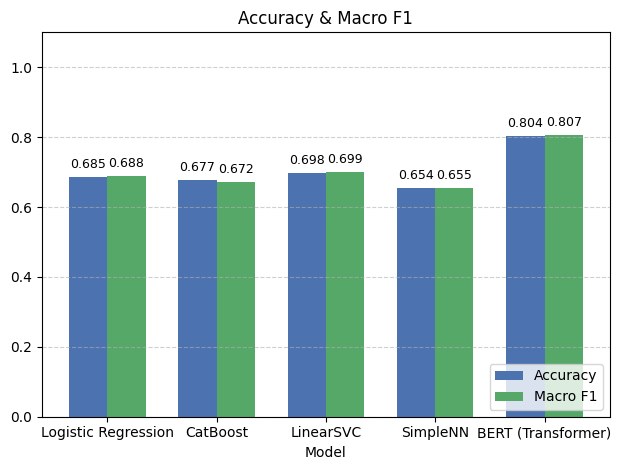

In [162]:
plt.figure(figsize=(10, 6))
ax = results_df[['Accuracy', 'Macro F1']].plot(
    kind='bar', rot=0, color=['#4c72b0', '#55a868'], width=0.7)
plt.title('Accuracy & Macro F1')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(loc='lower right')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

### Реализация Телеграм-бота

Разработка интерактивного сервиса (Телеграм-бота), который использует дообученную модель bert-base-uncased для анализа тональности англоязычных сообщений в реальном времени. Данный прототип демонстрирует возможность интеграции модели машинного обучения в пользовательские приложения.

Алгоритм работы бота:

1. Получение сообщения: Бот принимает от пользователя произвольный текст на английском языке.
2. Токенизация: Входной текст обрабатывается токенизатором BERT: приводится к нижнему регистру, разбивается на токены, ограничивается длиной контекста (128 токенов) и дополняется специальными служебными символами.
3. Инференс модели: Подготовленные тензоры подаются на вход нейросети SentimentClassifier для вычисления предсказаний.
4. Постобработка: Выходные значения (логиты) преобразуются в вероятности с помощью функции Softmax.
5. Результат: Бот возвращает пользователю определенный класс тональности (Positive, Neutral, Negative) и степень уверенности модели в этом предсказании (в процентах).

In [163]:
!pip install python-telegram-bot nest_asyncio transformers torch beautifulsoup4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.0/731.0 kB 34.3 MB/s eta 0:00:00


In [ ]:
import os
import logging
import nest_asyncio
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import BertTokenizer, AutoModel
from telegram import Update
from telegram.ext import (
    ApplicationBuilder,
    CommandHandler,
    MessageHandler,
    ContextTypes,
    filters,
)

nest_asyncio.apply()

# 1. Настройки и Логирование
logging.basicConfig(
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s', level=logging.INFO
)
logger = logging.getLogger(__name__)

# КОНФИГУРАЦИЯ
TOKEN = "*****"
MODEL_PATH = "best_bert_model.pth"
MODEL_NAME = "bert-base-uncased"
MAX_LEN = 128

# 2. Определение класса модели
class SentimentClassifier(nn.Module):
    def __init__(self, model_name=MODEL_NAME, n_classes=3, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, n_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.pooler_output
        return self.classifier(self.dropout(pooled))

# 3. Инициализация глобальных переменных
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Загружаем токенизатор
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

# Загружаем модель
model = SentimentClassifier(n_classes=3).to(device)

try:
    if os.path.exists(MODEL_PATH):
        model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
        model.eval()
        logger.info("Модель успешно загружена.")
    else:
        logger.error(f"Файл {MODEL_PATH} не найден! Бот будет работать с необученной моделью (мусор на выходе).")
except Exception as e:
    logger.error(f"Ошибка при загрузке весов: {e}")

# Словарь меток
labels_map = {0: '🔴 Negative', 1: '⚪ Neutral', 2: '🟢 Positive'}

# 4. Функция предсказания
def predict_sentiment(text: str) -> str:
    try:
        # Препроцессинг
        enc = tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=MAX_LEN,
            return_tensors='pt'
        )
        input_ids = enc['input_ids'].to(device)
        attn_mask = enc['attention_mask'].to(device)

        # Инференс
        with torch.no_grad():
            outputs = model(input_ids, attn_mask)
            # Превращаем логиты в вероятности (0..1)
            probs = F.softmax(outputs, dim=1).cpu().numpy()[0]

        # Выбор класса
        pred_idx = probs.argmax()
        confidence = probs[pred_idx]

        label_text = labels_map.get(pred_idx, "Unknown")
        return f"Result: {label_text}\nConfidence: {confidence:.2%}"

    except Exception as e:
        logger.error(f"Ошибка при предсказании: {e}")
        return "Ошибка при анализе текста."

# 5. Обработчики Telegram
async def start(update: Update, context: ContextTypes.DEFAULT_TYPE):
    await update.message.reply_text(
        "Send me any text in English, and I will detect if it's Positive, Neutral, or Negative."
    )

async def handle_message(update: Update, context: ContextTypes.DEFAULT_TYPE):
    user_text = update.message.text
    if not user_text:
        return

    # Логируем входящее сообщение (для отладки)
    logger.info(f"User: {user_text}")

    # Отправляем "печатает..." для красоты
    await context.bot.send_chat_action(chat_id=update.effective_chat.id, action='typing')

    # Получаем предсказание
    result = predict_sentiment(user_text)

    # Отправляем ответ
    await update.message.reply_text(result)

# 6. Основная функция запуска
def main():
    if TOKEN == "***" or not TOKEN:
        return

    app = ApplicationBuilder().token(TOKEN).build()

    # Регистрируем хендлеры
    app.add_handler(CommandHandler("start", start))
    app.add_handler(MessageHandler(filters.TEXT & ~filters.COMMAND, handle_message))

    print("Бот запущен...")
    app.run_polling()

if __name__ == "__main__":
    main()